In [9]:
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import pandas as pd
from datetime import datetime
import numpy as np
import pickle

In [10]:
df = pd.read_csv('../../data/processed/buli_matches_rolling.csv', index_col=0)

df['target'] = df['result_home'].map({"W": 0, "D":1, "L":2})
df['date'] = pd.to_datetime(df['date'])

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, labels=['H', 'D', 'A'], y_pred_override=None):
    # Predict train and test
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test) if y_pred_override is None else y_pred_override

    # Handle torch tensors
    if isinstance(y_pred_train, torch.Tensor):
        y_pred_test = np.reshape(y_pred_test.numpy(), len(y_test)) if isinstance(y_pred_test, torch.Tensor) else y_pred_test
        y_pred_train = np.reshape(y_pred_train.numpy(), len(y_train))

    # Accuracy
    train_accuracy = (sum(y_pred_train == y_train) / len(y_train)) * 100
    test_accuracy = (sum(y_pred_test == y_test) / len(y_test)) * 100

    print(f"Train accuracy: {train_accuracy:.2f}, Test accuracy: {test_accuracy:.2f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()

X_train_shape: (1011, 13),  y_train_shape: (1011,)
X_test_shape: (235, 13),  y_test_shape: (235,)
Test accuracy: 0.6723404255319149
Train accuracy: 68.74, Test accuracy: 67.23


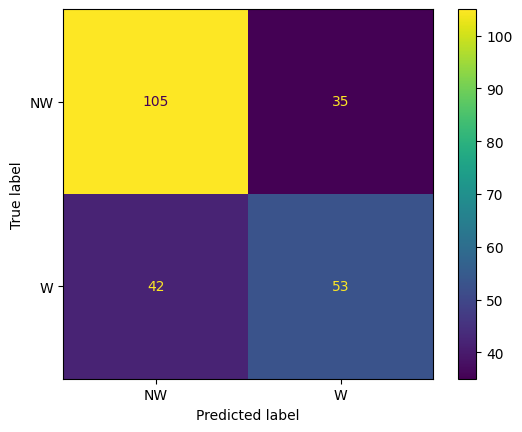

In [12]:
from sklearn import metrics
from xgboost import XGBClassifier

features = [
    "xg_home_rolling_3",
    "xg_away_rolling_3",
    "elo_home_rolling_3",
    "elo_away_rolling_3",
    "elo_rolling_diff",           # Combined team strength
    "xg_rolling_diff",            # Attack quality difference
    "goal_ratio_diff",            # Recent scoring form
    "ga_per_xGA_diff",            # Defense efficiency diff
    "gf_per_xG_diff",             # Offense efficiency diff
    "elo_diff_x_xg_diff",         # Interaction term, might capture outliers --> draws?
    "elo_diff_sq",

    # "days_since_home",            # Rest days (can impact performance)
    # "days_since_away",

    "goal_ratio_home_rolling_1",
    "goal_ratio_away_rolling_1",

    # "match_hour",
    # "day_code",
    # "week",

    # "poss_home_rolling_3",
    # "sot_home_rolling_3",
    # "poss_away_rolling_3",
    # "sot_away_rolling_3",
    # "xg_away_rolling_3",
    # "xg_home_rolling_3"
]

cutoff_date = pd.to_datetime('2024-05-01')
X_train = df[df['date'] < cutoff_date][features].to_numpy()
y_train = df[df['date'] < cutoff_date]['home_won'].to_numpy()
X_test = df[df['date'] >= cutoff_date][features].to_numpy()
y_test = df[df['date'] >= cutoff_date]['home_won'].to_numpy()


print(F"X_train_shape: {X_train.shape},  y_train_shape: {y_train.shape}")
print(F"X_test_shape: {X_test.shape},  y_test_shape: {y_test.shape}")

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=2,
    max_depth=4,           
    n_estimators=100,       
    learning_rate=0.1,
    reg_alpha = 10,
    reg_lambda = 5
)

xgb_clf.fit(X_train, y_train)

y_pred_test = xgb_clf.predict(X_test)
print(f"Test accuracy: {metrics.accuracy_score(y_pred=y_pred_test, y_true=y_test)}")

evaluate_model(xgb_clf, X_train, X_test, y_train, y_test, labels=['NW', 'W'])

with open('./model_win_loose.pkl', 'wb') as f:
    pickle.dump(xgb_clf, f)


In [13]:
print(metrics.classification_report(y_true=y_test, y_pred=y_pred_test))
train_df = df[df['date'] < cutoff_date]['home_won']

train_df.value_counts() / len(train_df)

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       140
           1       0.60      0.56      0.58        95

    accuracy                           0.67       235
   macro avg       0.66      0.65      0.66       235
weighted avg       0.67      0.67      0.67       235



home_won
0    0.556874
1    0.443126
Name: count, dtype: float64

X_train_shape: (1011, 1),  y_train_shape: (1011,)
X_test_shape: (235, 1),  y_test_shape: (235,)
Train accuracy: 52.13, Test accuracy: 51.06


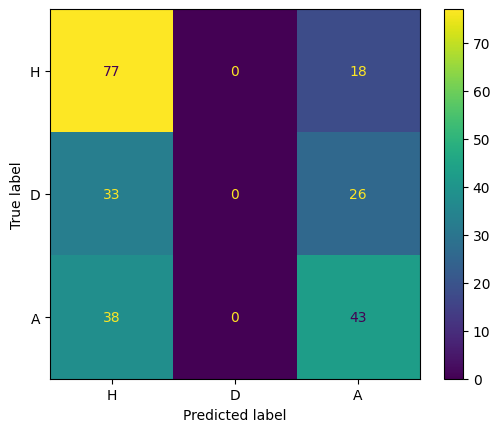

In [19]:
from sklearn import metrics
from xgboost import XGBClassifier

features = [
    # "xg_home_rolling_3",
    # "xg_away_rolling_3",
    # "elo_home_rolling_3",
    # "elo_away_rolling_3",
     "elo_rolling_diff",           # Combined team strength
    # "xg_rolling_diff",            # Attack quality difference
    # "goal_ratio_diff",            # Recent scoring form
    # "ga_per_xGA_diff",            # Defense efficiency diff
    # "gf_per_xG_diff",             # Offense efficiency diff
    # "elo_diff_x_xg_diff",         # Interaction term, might capture outliers --> draws?
    # "elo_diff_sq",

    # "days_since_home",            # Rest days (can impact performance)
    # "days_since_away",

    # "goal_ratio_home_rolling_1",
    # "goal_ratio_away_rolling_1",

    # "match_hour",
    # "day_code",
    # "week",

    # "poss_home_rolling_3",
    # "sot_home_rolling_3",
    # "poss_away_rolling_3",
    # "sot_away_rolling_3",
    # "xg_away_rolling_3",
    # "xg_home_rolling_3"
]

cutoff_date = pd.to_datetime('2024-05-01')
X_train = df[df['date'] < cutoff_date][features].to_numpy()
y_train = df[df['date'] < cutoff_date]['target'].to_numpy()
X_test = df[df['date'] >= cutoff_date][features].to_numpy()
y_test = df[df['date'] >= cutoff_date]['target'].to_numpy()

print(F"X_train_shape: {X_train.shape},  y_train_shape: {y_train.shape}")
print(F"X_test_shape: {X_test.shape},  y_test_shape: {y_test.shape}")

xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    max_depth=2,           
    n_estimators=100,       
    learning_rate=0.1,
    reg_alpha = 10,
    reg_lambda = 5
)

xgb_clf.fit(X_train, y_train)

y_pred_test_proba = xgb_clf.predict_proba(X_test)

y_pred_test = [np.argmax(p) for p in y_pred_test_proba]

evaluate_model(xgb_clf, X_train, X_test, y_train, y_test, y_pred_override=y_pred_test)
with open('./model_win_draw_loose.pkl', 'wb') as f:
    pickle.dump(xgb_clf, f)

In [15]:
print(metrics.classification_report(y_true=y_test, y_pred=y_pred_test))
train_df = df[df['date'] < cutoff_date]['target']

train_df.value_counts() / len(train_df)

              precision    recall  f1-score   support

           0       0.48      0.81      0.60        95
           1       0.10      0.02      0.03        59
           2       0.48      0.38      0.42        81

    accuracy                           0.46       235
   macro avg       0.35      0.40      0.35       235
weighted avg       0.38      0.46      0.40       235



target
0    0.443126
2    0.310584
1    0.246291
Name: count, dtype: float64